In [ ]:
%reset -f

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Solar_Energy_Production.csv")
df['date'] = pd.to_datetime(df.date, format="%Y/%m/%d %I:%M:%S %p")
df = df.set_index("date", drop=False)
display(df)

,name,id,address,date,kWh,public_url,installationDate,uid
date,,,,,,,,
2017-09-11 08:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 08:00:00,1.130,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 08:00:00
2017-09-11 09:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 09:00:00,2.340,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 09:00:00
2017-09-11 10:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 10:00:00,3.656,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 10:00:00
2017-09-11 11:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 11:00:00,4.577,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 11:00:00
2017-09-11 12:00:00,Calgary Fire Hall Headquarters,314106,1212 42 AV SE,2017-09-11 12:00:00,6.506,https://monitoring.solaredge.com/solaredge-web...,2016/11/07,3141062017-09-11 12:00:00
...,...,...,...,...,...,...,...,...
2023-03-12 15:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 15:00:00,201.285,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 15:00:00
2023-03-12 16:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 16:00:00,162.582,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 16:00:00
2023-03-12 17:00:00,Bearspaw Water Treatment Plant,577650,11444 Bearspaw Dam RD NW,2023-03-12 17:00:00,107.060,https://monitoringpublic.solaredge.com/solared...,2017/10/31,5776502023-03-12 17:00:00


In [ ]:
print(df.address.unique().size)

11


There are 11 distinct sites, identifiable with ID or address

In [ ]:
display(df.date.head(), df.date.tail())

,date
date,
2017-09-11 08:00:00,2017-09-11 08:00:00
2017-09-11 09:00:00,2017-09-11 09:00:00
2017-09-11 10:00:00,2017-09-11 10:00:00
2017-09-11 11:00:00,2017-09-11 11:00:00
2017-09-11 12:00:00,2017-09-11 12:00:00


,date
date,
2023-03-12 15:00:00,2023-03-12 15:00:00
2023-03-12 16:00:00,2023-03-12 16:00:00
2023-03-12 17:00:00,2023-03-12 17:00:00
2023-03-12 18:00:00,2023-03-12 18:00:00
2023-03-12 19:00:00,2023-03-12 19:00:00


It looks like time is continuous by the hour, however not all sites may have entries for a certain time, shown by the distribution on kaggle

Output is recorded as kWh produced in the timespan, shown on kaggle

In [ ]:
display(
    df.groupby("name").date.agg(start_date="min", end_date="max")
)

,start_date,end_date
name,,
Bearspaw Water Treatment Plant,2017-11-21 10:45:00,2023-03-16 19:00:00
CFD Firehall #7,2017-09-21 07:00:00,2023-03-16 19:00:00
Calgary Fire Hall Headquarters,2016-11-24 14:00:00,2023-03-16 19:00:00
City of Calgary North Corporate Warehouse,2016-12-23 09:30:00,2023-03-16 19:00:00
Glenmore Water Treatment Plant,2017-03-08 10:00:00,2023-03-12 17:00:00
Hillhurst Sunnyside Community Association,2016-10-03 13:00:00,2023-03-15 19:00:00
Manchester Building M,2017-10-05 13:15:00,2023-03-16 19:00:00
Richmond - Knob Hill Community Hall,2016-12-09 11:00:00,2023-03-16 19:00:00
Southland Leisure Centre,2015-09-01 14:30:00,2023-03-16 18:00:00


Looks like these sites have all been comissioned at slightly different times, and only one has been decomissioned early, in 2018.
Most others have data that stops at 03/2023.

In [ ]:
df['month'] = df.index.month
#df['year'] = df.index.year
df['hour'] = df.index.hour
df['day'] = df.index.day
target_building = "Whitehorn Multi-Service Centre"

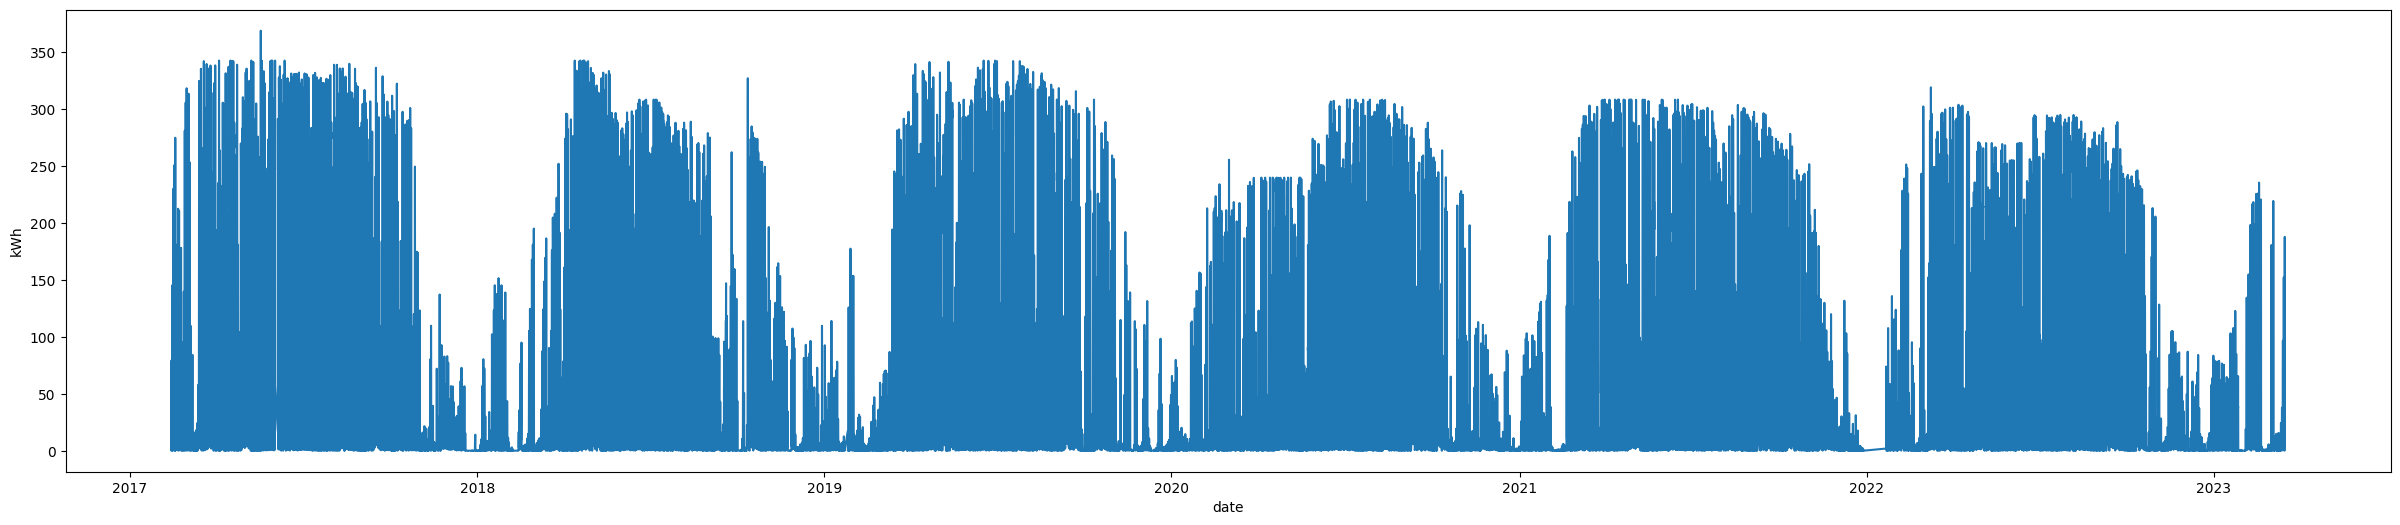

In [ ]:
plt.figure(figsize=(30, 6))
sns.lineplot(df[df.name == target_building], x="date", y="kWh")
plt.show()

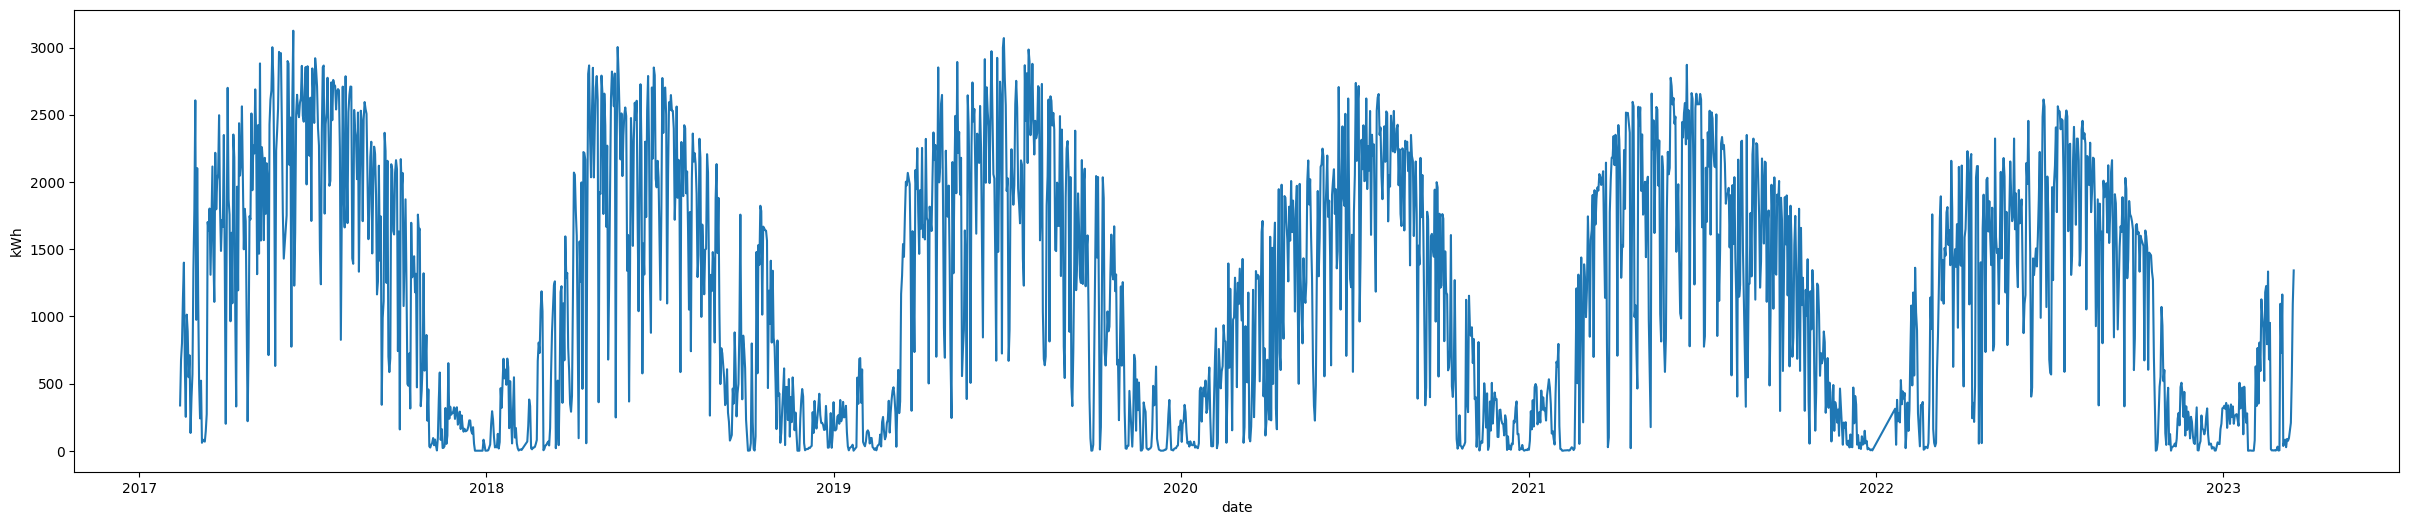

In [ ]:
df_by_day = df.groupby(["name", pd.Grouper(freq="D")]).agg(
    {
        'kWh': 'sum',
        'month': 'first'
    }
)

target = df_by_day.xs(target_building, level='name')

plt.figure(figsize=(30, 6))
sns.lineplot(data = target, x = target.index, y="kWh")
plt.show()

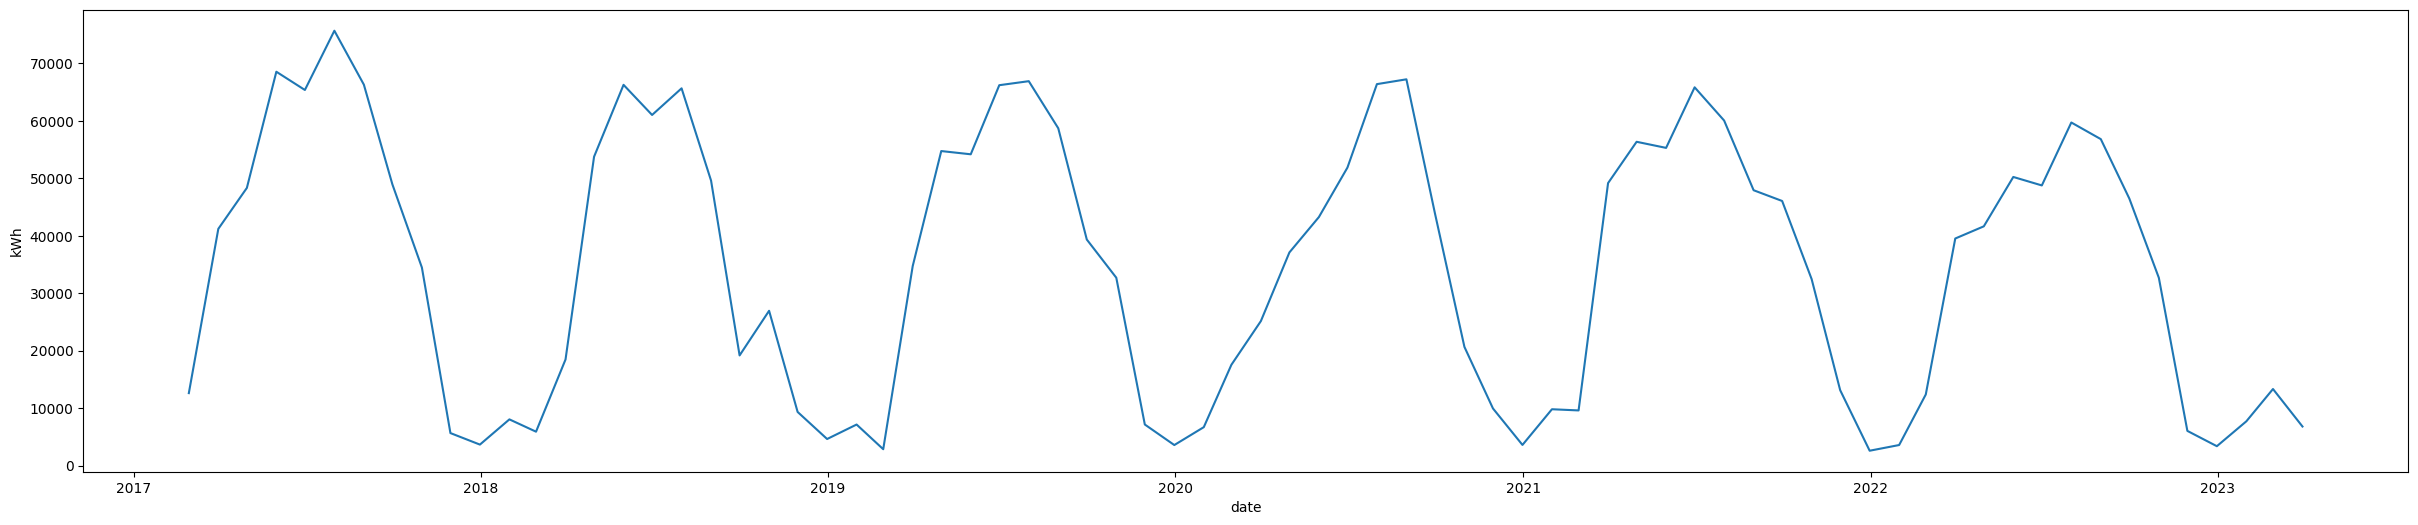

In [ ]:
df_by_month = df.groupby(["name", pd.Grouper(freq="ME")]).agg(
    {
        'kWh': 'sum',
        'month': 'first'
    }
)
target = df_by_month.xs(target_building, level='name')
plt.figure(figsize=(30, 6))
sns.lineplot(data = target, x = target.index, y="kWh")
plt.show()

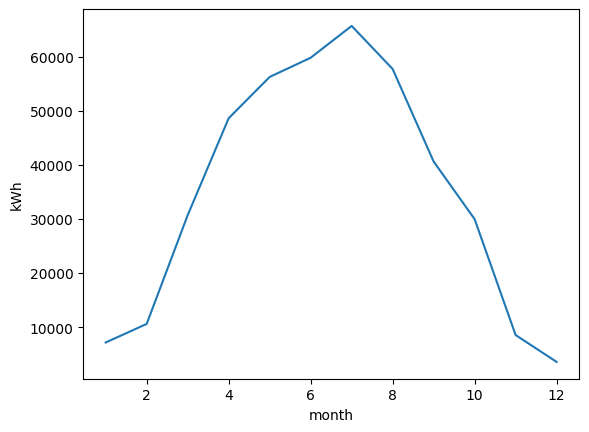

In [ ]:

target = df_by_month.xs(target_building, level = 'name')

target = target.groupby("month").mean()
sns.lineplot(data = target, x = 'month', y = 'kWh')
plt.show()

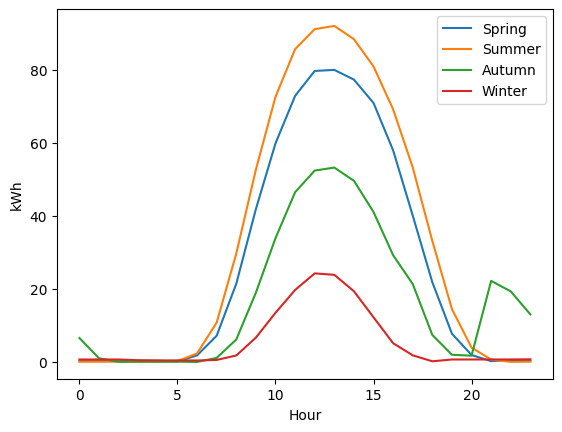

In [ ]:
df_spring = df[(df.month == 3) | (df.month == 4) | (df.month == 5)]
df_summer = df[(df.month == 6) | (df.month == 7) | (df.month == 8)]
df_autumn = df[(df.month == 9) | (df.month == 10) | (df.month == 11)]
df_winter = df[(df.month == 12) | (df.month == 1) | (df.month == 2)]

dfs = [df_spring, df_summer, df_autumn, df_winter]

target_spring = df_spring.groupby(df_spring.index.hour).agg(
    {'kWh': 'mean'}
)
target_summer = df_summer.groupby(df_summer.index.hour).agg(
    {'kWh': 'mean'}
)
target_autumn = df_autumn.groupby(df_autumn.index.hour).agg(
    {'kWh': 'mean'}
)
target_winter = df_winter.groupby(df_winter.index.hour).agg(
    {'kWh': 'mean'}
)

targets = [target_spring, target_summer, target_autumn, target_winter]

for index, season in enumerate(targets):
    sns.lineplot(data=season, x=season.index, y='kWh', label=['Spring', 'Summer', 'Autumn', 'Winter'][index])

plt.xlabel("Hour")

plt.legend()
plt.show()

In [ ]:
# Find out about the wierd spike in late hours for autumn.
target = df_autumn[(df_autumn.index.hour > 20) & (df_autumn.kWh > 1)]
display(target) # Looks like southland is consistently wierd numbers at midnight

,name,id,address,date,kWh,public_url,installationDate,uid,month,hour,day
date,,,,,,,,,,,
2015-09-01 21:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-01 21:30:00,57.844,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-01 21:30:00,9,21,1
2015-09-01 22:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-01 22:30:00,48.606,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-01 22:30:00,9,22,1
2015-09-01 23:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-01 23:30:00,31.482,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-01 23:30:00,9,23,1
2015-09-02 21:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-02 21:30:00,35.959,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-02 21:30:00,9,21,2
2015-09-02 22:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-02 22:30:00,57.311,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-02 22:30:00,9,22,2
2015-09-02 23:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-02 23:30:00,13.246,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-02 23:30:00,9,23,2
2015-09-03 21:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-03 21:30:00,53.896,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-03 21:30:00,9,21,3
2015-09-03 22:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-03 22:30:00,47.704,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-03 22:30:00,9,22,3
2015-09-03 23:30:00,Southland Leisure Centre,164440,2000 SOUTHLAND DR SW,2015-09-03 23:30:00,41.221,https://monitoring.solaredge.com/solaredge-web...,2015/09/01,1644402015-09-03 23:30:00,9,23,3


Good candidates:
Whitehorn,
Manchester (clean time range),
Richmond



In [ ]:
data = df[(df.name == "Whitehorn Multi-Service Centre") & (df.date > pd.to_datetime("2020", format="%Y"))].copy()



In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from numpy import sin, cos, pi, ptp

#data['hour_sin'] = sin(2 * pi * data['hour'] / 24.0)
#data['hour_cos'] = cos(2 * pi * data['hour'] / 24.0)

#data['month_sin'] = sin(2 * pi * data['hour'] / 12.0)
#data['month_cos'] = cos(2 * pi * data['hour'] / 12.0)

#data['kWh_lag1'] = data['kWh'].shift(1)
#data['kWh_lag2'] = data['kWh'].shift(2)

#data['kWh_lag24'] = data['kWh'].shift(24)

data['DOY'] = data.date.dt.dayofyear - 1
data = data.copy()

#data['DOY_sin'] = sin(2 * pi * data['hour'] / 365.0)
#data['DOY_cos'] = cos(2 * pi * data['hour'] / 365.0)

def add_lag_features(df, target_col, lags):
    """Generates lag features for a given target column and list of lag intervals."""
    df = df.copy()
    for lag in lags:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)
    return df


# Specify the exact lags you want (e.g., 1 to 3 hours, 24 hours, 168 hours for 1 week)
lag_steps = [1, 2, 3, 6, 12, 24, 48, 168]

data = add_lag_features(data, target_col="kWh", lags=lag_steps)
data = data.iloc[168:]


32.559729624551196 0.8607327664670426 19.927547489997895 24.650682458043462
Index(['name', 'id', 'address', 'date', 'kWh', 'public_url',
       'installationDate', 'uid', 'month', 'hour', 'day', 'DOY', 'kWh_lag_1',
       'kWh_lag_2', 'kWh_lag_3', 'kWh_lag_6', 'kWh_lag_12', 'kWh_lag_24',
       'kWh_lag_48', 'kWh_lag_168'],
      dtype='object')


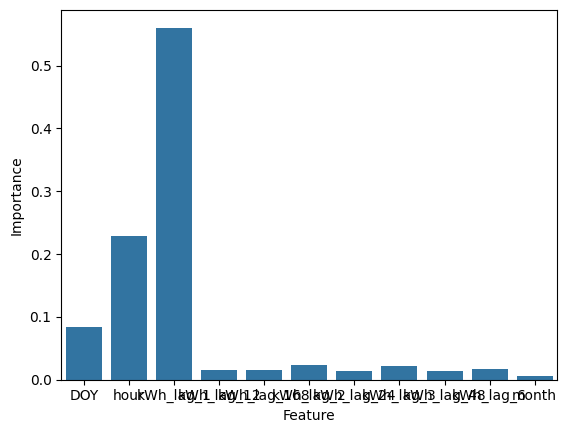

In [ ]:
from sklearn.metrics import root_mean_squared_error, r2_score, mean_absolute_error
from numpy import sum, abs
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
#x = data[['month', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24', 'date']] # 31.564038317246762 0.8667215192040549 18.660708832684822
features = data.columns.difference(['kWh', 'date', 'name', 'id', 'address', 'installationDate', 'public_url', 'uid', 'day'])
x = data[features]
y = data['kWh']

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = RandomForestRegressor(n_estimators=100, random_state=69420)

model.fit(train_x, train_y)

predictions = model.predict(test_x)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)
print(data.columns)
ax = sns.barplot(x=test_x.columns, y = model.feature_importances_)
ax.set(xlabel = "Feature", ylabel = "Importance")
plt.show()

In [ ]:
%%script true
test_data = pd.DataFrame()
test_data['date'] = test_x['date']
test_data['pred'] = predictions
test_data['real'] = test_y
test_data = test_data[(test_data['date'] > pd.to_datetime('3/2/2023', format="%m/%d/%Y")) & (test_data['date'] < pd.to_datetime('3/3/2023', format="%m/%d/%Y"))]
ax = sns.lineplot(x=test_data['date'], y = test_data['pred'])
ax2 = ax.twinx()
sns.lineplot(x=test_data['date'], y = test_data['real'], color='orange')

In [ ]:
from xgboost import XGBRegressor
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
x = data[features] # 31.564038317246762 0.8667215192040549 18.660708832684822
y = data['kWh']

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511)


model.fit(train_x, train_y)

predictions = model.predict(test_x)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)

importance = pd.Series(
    model.feature_importances_, index=train_x.columns
)
print("\nFeature Importances:\n", importance.sort_values(ascending=False))

31.655708609505904 0.8684942618821117 20.09441385658005 24.83675874789676

Feature Importances:
 kWh_lag_1      0.467996
hour           0.211197
month          0.078721
DOY            0.063131
kWh_lag_2      0.059066
kWh_lag_3      0.031636
kWh_lag_6      0.021139
kWh_lag_12     0.017233
kWh_lag_48     0.017102
kWh_lag_168    0.016688
kWh_lag_24     0.016092
dtype: float32


In [ ]:
#%%script true
!pip install optuna
import optuna
def objective(trial):
    # Define hyperparameter ranges to sample
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 69420,
    }

    model = XGBRegressor(**params)
    model.fit(train_x, train_y)

    preds = model.predict(test_x)
    # Objective is to minimize RMSE on test/validation set
    rmse = root_mean_squared_error(test_y, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)

[I 2026-08-07 13:49:33,709] A new study created in memory with name: no-name-730c6cce-4286-4440-8ba2-6417ce953a21
[I 2026-08-07 13:49:34,133] Trial 0 finished with value: 32.64039537757778 and parameters: {'n_estimators': 113, 'learning_rate': 0.06753582965745547, 'max_depth': 6, 'subsample': 0.882856376733473, 'colsample_bytree': 0.8908349879912998}. Best is trial 0 with value: 32.64039537757778.
[I 2026-08-07 13:49:34,181] Trial 1 finished with value: 48.89122118517587 and parameters: {'n_estimators': 53, 'learning_rate': 0.01956311303482726, 'max_depth': 5, 'subsample': 0.8369161528959684, 'colsample_bytree': 0.8406917275305863}. Best is trial 0 with value: 32.64039537757778.
[I 2026-08-07 13:49:34,448] Trial 2 finished with value: 32.12747224928004 and parameters: {'n_estimators': 227, 'learning_rate': 0.03364222087241367, 'max_depth': 7, 'subsample': 0.7583626476846373, 'colsample_bytree': 0.8444026137100447}. Best is trial 2 with value: 32.12747224928004.
[I 2026-08-07 13:49:34,6

Best Parameters: {'n_estimators': 276, 'learning_rate': 0.023343576736722382, 'max_depth': 8, 'subsample': 0.9348862155045096, 'colsample_bytree': 0.9562632268366563}


In [ ]:
from lightgbm import LGBMRegressor
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
x = data[features] # 31.564038317246762 0.8667215192040549 18.660708832684822
y = data['kWh']

split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
test_x = x[split_idx:]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511)


model.fit(train_x, train_y)

predictions = model.predict(test_x)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)

31.547821200272953 0.8692546926059824 19.988706419003805 24.72633699301097


In [ ]:
%%script true
def objective_lgbm(trial):
    # Define hyperparameter ranges to sample
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float(
            "learning_rate", 0.01, 0.2, log=True
        ),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "num_leaves": trial.suggest_int("num_leaves", 15, 63),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": trial.suggest_int("subsample_freq", 1, 5),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 69420,
    }

    model = LightGBMRegressor(**params)
    model.fit(train_x, train_y)

    preds = model.predict(test_x)
    # Objective is to minimize RMSE on test/validation set
    rmse = root_mean_squared_error(test_y, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=200)

print("Best Parameters:", study.best_params)

In [ ]:
LATITUDE = 51.08570494734326  # Your panel latitude
LONGITUDE = -113.98363752368412  # Your panel longitude
START_DATE = "2020-01-01"
END_DATE = "2023-03-16"

In [ ]:
#%%script true
import requests

# 2. Build Open-Meteo URL requesting solar-specific variables
url = (
    f"https://archive-api.open-meteo.com/v1/archive?"
    f"latitude={LATITUDE}&longitude={LONGITUDE}&"
    f"start_date={START_DATE}&end_date={END_DATE}&"
    f"hourly=temperature_2m,cloud_cover,direct_normal_irradiance,diffuse_radiation,relative_humidity_2m&"
    f"timezone=GMT"
)

# 3. Fetch data and build DataFrame
response = requests.get(url).json()
weather_df = pd.DataFrame(response["hourly"])

# 4. Format timestamp for clean merging
weather_df["date"] = pd.to_datetime(weather_df["time"])
weather_df = weather_df.drop(columns=["time"])
weather_df['date'] = pd.to_datetime(weather_df['date']).dt.tz_localize('UTC')

print(weather_df.head())

weather_df.to_csv("Whitehorn_weather.csv", index=False)

   temperature_2m  cloud_cover  direct_normal_irradiance  diffuse_radiation  \
0             1.1          100                       0.0                3.0   
1             0.8          100                       0.0                0.0   
2             0.5           96                       0.0                0.0   
3             0.8           99                       0.0                0.0   
4             0.7           98                       0.0                0.0   

   relative_humidity_2m                      date  
0                    68 2020-01-01 00:00:00+00:00  
1                    68 2020-01-01 01:00:00+00:00  
2                    68 2020-01-01 02:00:00+00:00  
3                    67 2020-01-01 03:00:00+00:00  
4                    68 2020-01-01 04:00:00+00:00  


In [ ]:
weather_df = pd.read_csv("Whitehorn_weather.csv")
weather_df['date'] = pd.to_datetime(weather_df['date'])

In [ ]:
import pvlib
data = df[(df.name == "Whitehorn Multi-Service Centre") & (df.date > pd.to_datetime("2020", format="%Y"))].copy()
data = data[data.columns.difference(['name', 'id', 'address', 'installationDate', 'public_url', 'uid'])]

data['date'] = data['date'].dt.tz_localize('America/Edmonton').dt.tz_convert('UTC')

data = data.reset_index(drop=True)
weather_df = weather_df.reset_index(drop=True)

data = pd.merge(data, weather_df, on='date', how="inner", suffixes=("", "_weather"))

data.dropna().sort_values('date').reset_index(drop=True)
data.set_index('date', drop=False)

times = pd.date_range("2020-01-01 00:00", "2023-03-16 23:00", freq="h", tz="UTC")
solpos = pvlib.solarposition.get_solarposition(times, LATITUDE, LONGITUDE)
elevation_df = pd.DataFrame ({
    'date': times,
    'elevation': solpos.elevation
})

data = pd.merge(data, elevation_df, on='date', how='inner', suffixes=('', '_elevation'))
data.dropna().sort_values('date').reset_index(drop=True)
data.set_index('date', drop=False)

lag_steps = [1, 2, 3, 6, 12, 24, 48, 168]

data = add_lag_features(data, target_col="kWh", lags=lag_steps)
data = data.iloc[168:]


In [ ]:
data['DOY'] = data.date.dt.dayofyear - 1
data = data.copy()

In [ ]:
from xgboost import XGBRegressor
#x = data[['month_sin', 'month_cos', 'DOY_sin', 'DOY_cos', 'hour_sin', 'hour_cos', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 36.254364760678094 0.8248486389497924 23.46417641279728
#x = data[['month', 'DOY', 'hour', 'kWh_lag1', 'kWh_lag2', 'kWh_lag24']] # 31.12005383704525 0.8705738726313695 18.335540267154105
#x = data[['month', 'DOY', 'hour']] # 60.92139135385213 0.504242367929508 38.9335652916937
x = data[data.columns.difference(['kWh', 'day'])] # 31.564038317246762 0.8667215192040549 18.660708832684822
y = data['kWh']


split_idx = int(len(data) * (2 / 3))

train_x = x[:split_idx]
display(train_x.columns)
train_x = train_x[train_x.columns.difference(['date'])]

test_x = x[split_idx:]
test_x_no_date = test_x[test_x.columns.difference(['date'])]
train_y = y[:split_idx]
test_y = y[split_idx:]

model = XGBRegressor(n_estimators=274, random_state=69420, learning_rate=0.016402891919412303, max_depth=8, subsample=0.6358289534884547, colsample_bytree=0.921776337426511)


model.fit(train_x, train_y)

predictions = model.predict(test_x_no_date)

rmse = root_mean_squared_error(test_y, predictions)
r2 = r2_score(test_y, predictions)
mae = mean_absolute_error(test_y, predictions)
wape = (sum(abs(test_y - predictions)) / sum(test_y)) * 100
print(rmse, r2, mae, wape)

importance = pd.Series(
    model.feature_importances_, index=train_x.columns
)
print("\nFeature Importances:\n", importance.sort_values(ascending=False))

Index(['DOY', 'cloud_cover', 'date', 'diffuse_radiation',
       'direct_normal_irradiance', 'elevation', 'hour', 'kWh_lag_1',
       'kWh_lag_12', 'kWh_lag_168', 'kWh_lag_2', 'kWh_lag_24', 'kWh_lag_3',
       'kWh_lag_48', 'kWh_lag_6', 'month', 'relative_humidity_2m',
       'temperature_2m'],
      dtype='object')

28.22121946383649 0.8954817387692838 16.852975254651504 20.830330437679763

Feature Importances:
 elevation                   0.494498
kWh_lag_1                   0.157113
hour                        0.082396
direct_normal_irradiance    0.060395
temperature_2m              0.034951
cloud_cover                 0.028796
diffuse_radiation           0.019391
relative_humidity_2m        0.017167
kWh_lag_2                   0.016530
kWh_lag_3                   0.014321
month                       0.011568
kWh_lag_6                   0.011211
kWh_lag_168                 0.010810
kWh_lag_48                  0.010697
kWh_lag_24                  0.010565
kWh_lag_12                  0.010005
DOY                         0.009585
dtype: float32


In [ ]:
!pip install optuna
import optuna
def objective(trial):
    # Define hyperparameter ranges to sample
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 300),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "random_state": 69420,
    }

    model = XGBRegressor(**params)
    model.fit(train_x, train_y)

    preds = model.predict(test_x)
    # Objective is to minimize RMSE on test/validation set
    rmse = root_mean_squared_error(test_y, preds)
    return rmse

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("Best Parameters:", study.best_params)

[I 2026-08-07 12:55:31,260] A new study created in memory with name: no-name-514e6f8d-8f99-4870-9ce3-63d2cd0ad7a0
[I 2026-08-07 12:55:31,394] Trial 0 finished with value: 41.347403779601215 and parameters: {'n_estimators': 153, 'learning_rate': 0.010082570201010381, 'max_depth': 3, 'subsample': 0.9181419240168128, 'colsample_bytree': 0.8948420740964365}. Best is trial 0 with value: 41.347403779601215.
[I 2026-08-07 12:55:32,133] Trial 1 finished with value: 29.756681060685708 and parameters: {'n_estimators': 284, 'learning_rate': 0.032788634517588955, 'max_depth': 8, 'subsample': 0.7882753462827568, 'colsample_bytree': 0.8558252394245602}. Best is trial 1 with value: 29.756681060685708.
[I 2026-08-07 12:55:32,255] Trial 2 finished with value: 29.61223578820097 and parameters: {'n_estimators': 113, 'learning_rate': 0.04253226373867495, 'max_depth': 6, 'subsample': 0.8014490094891418, 'colsample_bytree': 0.7374753695014229}. Best is trial 2 with value: 29.61223578820097.
[I 2026-08-07 12

Best Parameters: {'n_estimators': 300, 'learning_rate': 0.024057796194020993, 'max_depth': 7, 'subsample': 0.8049059644866405, 'colsample_bytree': 0.8085589223458894}


<Axes: xlabel='date', ylabel='real'>

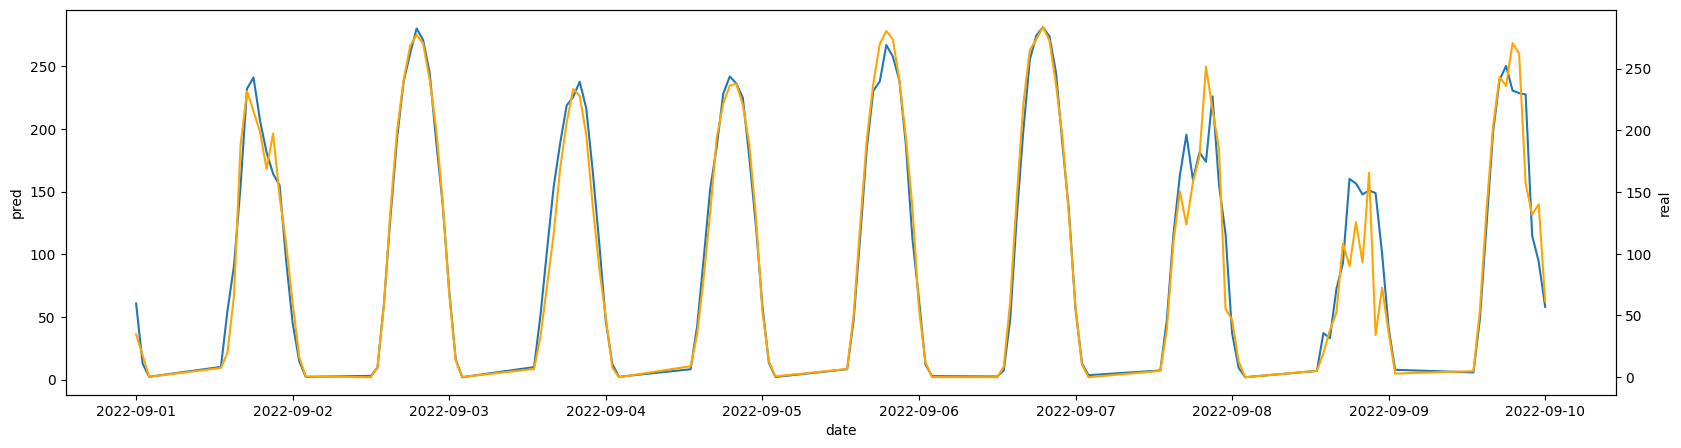

In [ ]:
res_df = pd.DataFrame({
    'date': test_x.date,
    'pred': predictions,
    'real': test_y
})

mask = (res_df['date'] >= '2022-09-01') & (res_df['date'] <= '2022-09-10')

res_df = res_df[mask]

plt.figure(figsize=(20, 5))
ax = sns.lineplot(x=res_df['date'], y = res_df['pred'])
ax2 = ax.twinx()
sns.lineplot(x=res_df['date'], y = res_df['real'], color='orange')